In [3]:
'''Analytic Task 1 — Shooting Accuracy

Analytic question: Do teams that reached the knockout stage have a higher average shooting accuracy than teams eliminated in the group stage at the 
FIFA World Cup 2026?

Population: All 48 teams that participated in the FIFA World Cup 2026.
Unit of observation: One national team.
Variable of interest: Shooting accuracy (%), calculated as shots on target divided by total shots × 100.
Groups: Knockout-stage teams and group-stage-eliminated teams.
Sampling frame: The 48 teams in the FBref Squad Shooting 2026 World Cup dataset.
Sampling method: Proportionate stratified random sampling.
Sample: 36 teams — 24 knockout-stage teams and 12 group-stage-eliminated teams.'''

'Analytic Task 1 — Shooting Accuracy\n\nAnalytic question: Do teams that reached the knockout stage have a higher average shooting accuracy than teams eliminated in the group stage at the \nFIFA World Cup 2026?\n\nPopulation: All 48 teams that participated in the FIFA World Cup 2026.\nUnit of observation: One national team.\nVariable of interest: Shooting accuracy (%), calculated as shots on target divided by total shots × 100.\nGroups: Knockout-stage teams and group-stage-eliminated teams.\nSampling frame: The 48 teams in the FBref Squad Shooting 2026 World Cup dataset.\nSampling method: Proportionate stratified random sampling.\nSample: 36 teams — 24 knockout-stage teams and 12 group-stage-eliminated teams.'

In [4]:
# Data preparation and validation

In [5]:
#imported pandas because I use it to work with tables and datasets.”
import pandas as pd


In [6]:
# Load the FBref squad shooting dataset
df = pd.read_csv("worldcup2026_squad_shooting.csv", skiprows=5)

df.head()

,Squad,# Pl,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt
0,dz Algeria,22,4.0,5,44,15,34.1,11.00,3.75,0.11,0.33,0,0
1,ar Argentina,24,9.0,18,114,44,38.6,12.67,4.89,0.16,0.41,1,3
2,au Australia,23,4.3,2,42,12,28.6,9.69,2.77,0.05,0.17,0,0
3,at Austria,20,4.0,5,32,8,25.0,8.00,2.00,0.16,0.63,1,1
4,be Belgium,23,6.3,13,112,34,30.4,17.68,5.37,0.12,0.38,1,1


In [7]:
# Keep only the columns needed for Task 1
shooting = df[['Squad', 'Sh', 'SoT', 'SoT%']].copy()

shooting.head()

,Squad,Sh,SoT,SoT%
0,dz Algeria,44,15,34.1
1,ar Argentina,114,44,38.6
2,au Australia,42,12,28.6
3,at Austria,32,8,25.0
4,be Belgium,112,34,30.4


In [8]:
# Clean the team names
shooting['Squad'] = shooting['Squad'].astype(str)

shooting['Squad'] = shooting['Squad'].str.split(' ', n=1).str[1]

shooting.head()


,Squad,Sh,SoT,SoT%
0,Algeria,44,15,34.1
1,Argentina,114,44,38.6
2,Australia,42,12,28.6
3,Austria,32,8,25.0
4,Belgium,112,34,30.4


In [9]:
# Calculate shooting accuracy 
shooting['Shooting_Accuracy'] = (
    shooting['SoT'] / shooting['Sh']
) * 100

shooting.head()

,Squad,Sh,SoT,SoT%,Shooting_Accuracy
0,Algeria,44,15,34.1,34.090909
1,Argentina,114,44,38.6,38.596491
2,Australia,42,12,28.6,28.571429
3,Austria,32,8,25.0,25.000000
4,Belgium,112,34,30.4,30.357143


In [10]:
# Check whether our calculated value matches FBref's value
shooting['Check'] = shooting['Shooting_Accuracy'] - shooting['SoT%']

shooting[['Squad', 'Shooting_Accuracy', 'SoT%', 'Check']].head()

,Squad,Shooting_Accuracy,SoT%,Check
0,Algeria,34.090909,34.1,-0.009091
1,Argentina,38.596491,38.6,-0.003509
2,Australia,28.571429,28.6,-0.028571
3,Austria,25.000000,25.0,0.000000
4,Belgium,30.357143,30.4,-0.042857


In [11]:
# Check the largest difference between our calculation and FBref's SoT%
print("Largest validation difference:", shooting['Check'].abs().max())

Largest validation difference: 0.04999999999999716


In [12]:
#Team classification

In [13]:
# Cell 7 — List the teams that reached the knockout stage

In [14]:
knockout_teams = [
    'South Africa', 'Canada', 'Brazil', 'Japan',
    'Germany', 'Paraguay', 'Netherlands', 'Morocco',
    "Côte d'Ivoire", 'Norway', 'France', 'Sweden',
    'Mexico', 'Ecuador', 'England', 'Congo DR',
    'Belgium', 'Senegal', 'USA', 'Bosnia–Herz',
    'Spain', 'Austria', 'Portugal', 'Croatia',
    'Switzerland', 'Algeria', 'Australia', 'Egypt',
    'Argentina', 'Cabo Verde', 'Colombia', 'Ghana'
]

In [15]:
# Cell 8 — Create a simple function

In [16]:
def find_stage(team):
    if team in knockout_teams:
        return 'Knockout'
    else:
        return 'Group Stage Eliminated'

In [17]:
shooting['Stage'] = shooting['Squad'].apply(find_stage)

In [18]:
# cell9 - check the classification

In [19]:
shooting['Stage'].value_counts()

Stage
Knockout                  32
Group Stage Eliminated    16
Name: count, dtype: int64

In [20]:
#Basic cleaning

In [21]:
print("Missing values:")
print(shooting.isnull().sum())

Missing values:
Squad                0
Sh                   0
SoT                  0
SoT%                 0
Shooting_Accuracy    0
Check                0
Stage                0
dtype: int64


In [22]:
print("Duplicate teams:")
print(shooting['Squad'].duplicated().sum())

Duplicate teams:
0


In [23]:
print("Teams with zero shots:")
print((shooting['Sh'] == 0).sum())

Teams with zero shots:
0


In [24]:
# Check that shots on target never exceed total shots
print("Invalid SoT values:")
print((shooting['SoT'] > shooting['Sh']).sum())

Invalid SoT values:
0


In [25]:
knockout = shooting[shooting['Stage'] == 'Knockout']

eliminated = shooting[
    shooting['Stage'] == 'Group Stage Eliminated'
]

knockout

,Squad,Sh,SoT,SoT%,Shooting_Accuracy,Check,Stage
0,Algeria,44,15,34.1,34.090909,-0.009091,Knockout
1,Argentina,114,44,38.6,38.596491,-0.003509,Knockout
2,Australia,42,12,28.6,28.571429,-0.028571,Knockout
3,Austria,32,8,25.0,25.000000,0.000000,Knockout
4,Belgium,112,34,30.4,30.357143,-0.042857,Knockout
5,Bosnia–Herz,37,14,37.8,37.837838,0.037838,Knockout
6,Brazil,74,30,40.5,40.540541,0.040541,Knockout
7,Cabo Verde,49,12,24.5,24.489796,-0.010204,Knockout
8,Canada,80,31,38.8,38.750000,-0.050000,Knockout
9,Colombia,94,30,31.9,31.914894,0.014894,Knockout


In [26]:
sample_knockout = knockout.sample(n=24, random_state=42)

sample_eliminated = eliminated.sample(n=12, random_state=42)

sample_knockout

,Squad,Sh,SoT,SoT%,Shooting_Accuracy,Check,Stage
41,Sweden,48,23,47.9,47.916667,0.016667,Knockout
17,England,118,53,44.9,44.915254,0.015254,Knockout
33,Paraguay,35,8,22.9,22.857143,-0.042857,Knockout
19,Germany,74,28,37.8,37.837838,0.037838,Knockout
8,Canada,80,31,38.8,38.750000,-0.050000,Knockout
9,Colombia,94,30,31.9,31.914894,0.014894,Knockout
42,Switzerland,74,30,40.5,40.540541,0.040541,Knockout
34,Portugal,62,17,27.4,27.419355,0.019355,Knockout
12,Croatia,37,17,45.9,45.945946,0.045946,Knockout
0,Algeria,44,15,34.1,34.090909,-0.009091,Knockout


In [27]:
sample = pd.concat([sample_knockout, sample_eliminated])

sample['Stage'].value_counts()

Stage
Knockout                  24
Group Stage Eliminated    12
Name: count, dtype: int64

In [28]:
'''SAMPLING EXPLANATION

The population contains 32 knockout-stage teams and
16 group-stage-eliminated teams.

I randomly sampled 24 knockout teams and 12 eliminated teams.
This preserved the original 2:1 group ratio
random_state=42 was used so the sample can be reproduced.'''

'SAMPLING EXPLANATION\n\nThe population contains 32 knockout-stage teams and\n16 group-stage-eliminated teams.\n\nI randomly sampled 24 knockout teams and 12 eliminated teams.\nThis preserved the original 2:1 group ratio\nrandom_state=42 was used so the sample can be reproduced.'

In [29]:
#Descriptive statistics

In [30]:
# Descriptive statistics for shooting accuracy
sample.groupby('Stage')['Shooting_Accuracy'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
Stage,,,,,,
Group Stage Eliminated,12,27.283693,24.137931,10.038285,9.523810,48.387097
Knockout,24,35.479009,37.708504,8.198950,16.666667,47.916667


In [31]:
#Simple visualisation

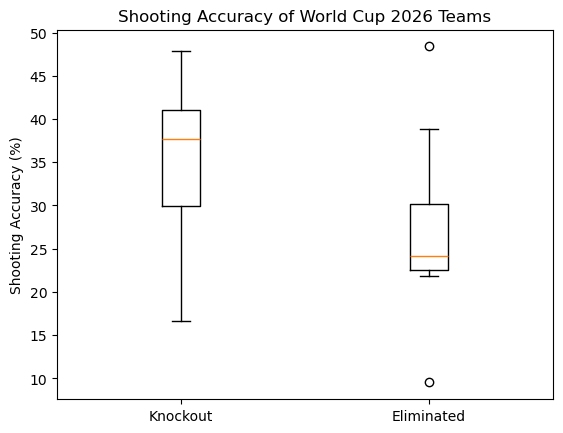

In [32]:
import matplotlib.pyplot as plt

# Separate shooting accuracy for the two groups
knockout_accuracy = sample[
    sample['Stage'] == 'Knockout'
]['Shooting_Accuracy']

eliminated_accuracy = sample[
    sample['Stage'] == 'Group Stage Eliminated'
]['Shooting_Accuracy']

# Create a boxplot
plt.boxplot(
    [knockout_accuracy, eliminated_accuracy],
    labels=['Knockout', 'Eliminated']
)

plt.ylabel('Shooting Accuracy (%)')
plt.title('Shooting Accuracy of World Cup 2026 Teams')

plt.show()

In [33]:
'''BOXPLOT INTERPRETATION

The boxplot suggests that knockout-stage teams generally had higher shooting accuracy than group-stage-eliminated teams. However, a hypothesis test is 
needed to determine whether this difference is statistically significant.'''

'BOXPLOT INTERPRETATION\n\nThe boxplot suggests that knockout-stage teams generally had higher shooting accuracy than group-stage-eliminated teams. However, a hypothesis test is \nneeded to determine whether this difference is statistically significant.'

In [34]:
# Next step: 95% confidence intervals

In [35]:
# Import the statistics function

In [36]:
from scipy import stats
import numpy as np

In [37]:
# calculate a 95% confidence interval for the mean shooting accuracy of knockout teams

In [38]:
# 95% confidence interval for knockout teams

mean_k = knockout_accuracy.mean()
std_k = knockout_accuracy.std()
n_k = len(knockout_accuracy)

ci_k = stats.t.interval(
    0.95,
    df=n_k - 1,
    loc=mean_k,
    scale=std_k / np.sqrt(n_k)
)

print("Knockout mean:", mean_k)
print("95% CI:", ci_k)

Knockout mean: 35.479009082544074
95% CI: (32.01689603281191, 38.94112213227624)


In [39]:
#Same for eliminated teams

In [41]:
# 95% confidence interval for eliminated teams

mean_e = eliminated_accuracy.mean()
std_e = eliminated_accuracy.std()
n_e = len(eliminated_accuracy)

ci_e = stats.t.interval(
    0.95,
    df=n_e - 1,
    loc=mean_e,
    scale=std_e / np.sqrt(n_e)
)

print("Eliminated mean:", mean_e)
print("95% CI:", ci_e)

Eliminated mean: 27.28369295601125
95% CI: (20.905670949919216, 33.66171496210329)


In [42]:
# Separate shooting accuracy for the two groups
knockout_accuracy = sample[
    sample['Stage'] == 'Knockout'
]['Shooting_Accuracy']

eliminated_accuracy = sample[
    sample['Stage'] == 'Group Stage Eliminated'
]['Shooting_Accuracy']

In [43]:
'''HYPOTHESIS TEST

Null hypothesis H0:
The mean shooting accuracy is the same for both groups.
H0: mean_knockout = mean_eliminated
Alternative hypothesis Ha:
Knockout-stage teams have a higher mean shooting accuracy.
Ha: mean_knockout > mean_eliminated'''

'HYPOTHESIS TEST\n\nNull hypothesis H0:\nThe mean shooting accuracy is the same for both groups.\nH0: mean_knockout = mean_eliminated\nAlternative hypothesis Ha:\nKnockout-stage teams have a higher mean shooting accuracy.\nHa: mean_knockout > mean_eliminated'

In [44]:
# Shapiro-wilk test

In [45]:
# Check normality of the two groups
print("Knockout:", stats.shapiro(knockout_accuracy))
print("Eliminated:", stats.shapiro(eliminated_accuracy))

Knockout: ShapiroResult(statistic=0.9703716518201464, pvalue=0.6761730464202125)
Eliminated: ShapiroResult(statistic=0.8978147012228888, pvalue=0.14864349271108762)


In [46]:
'''ASSUMPTION CHECK
Knockout Shapiro-Wilk p-value = 0.676
Eliminated Shapiro-Wilk p-value = 0.149
Both p-values are greater than 0.05.
Therefore, there is no significant evidence that either sample departs from normality.'''

'ASSUMPTION CHECK\nKnockout Shapiro-Wilk p-value = 0.676\nEliminated Shapiro-Wilk p-value = 0.149\nBoth p-values are greater than 0.05.\nTherefore, there is no significant evidence that either sample departs from normality.'

In [47]:
# two sample t test

In [48]:
# Two-sample t-test

t_stat, p_value = stats.ttest_ind(
    knockout_accuracy,
    eliminated_accuracy,
    equal_var=False,
    alternative='greater'
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.449014434842175
p-value: 0.012222016410452972


In [49]:
''' Since the p-value is below 0.05, there is statistically significant evidence that teams reaching the knockout stage had higher average
shooting accuracy than teams eliminated in the group stage.'''

' Since the p-value is below 0.05, there is statistically significant evidence that teams reaching the knockout stage had higher average\nshooting accuracy than teams eliminated in the group stage.'

In [50]:
'''CONCLUSION

Knockout-stage teams had a higher mean shooting accuracy: 35.48% compared with 27.28% for eliminated teams.

The difference in sample means was about 8.20 percentage points.

Welch two-sample t-test:
t = 2.449
p = 0.0122

Since p < 0.05, reject the null hypothesis.
There is statistically significant evidence that knockout-stage teams had higher average shooting accuracy than teams eliminated in the group stage.

LIMITATION:
FBref squad shooting statistics summarize each team's full tournament.
Knockout-stage teams therefore played more matches.
Using shooting accuracy instead of raw shot totals reduces the effect of unequal playing time, but different opponents and tournament stages may still 
influence the comparison.'''

"CONCLUSION\n\nKnockout-stage teams had a higher mean shooting accuracy: 35.48% compared with 27.28% for eliminated teams.\n\nThe difference in sample means was about 8.20 percentage points.\n\nWelch two-sample t-test:\nt = 2.449\np = 0.0122\n\nSince p < 0.05, reject the null hypothesis.\nThere is statistically significant evidence that knockout-stage teams had higher average shooting accuracy than teams eliminated in the group stage.\n\nLIMITATION:\nFBref squad shooting statistics summarize each team's full tournament.\nKnockout-stage teams therefore played more matches.\nUsing shooting accuracy instead of raw shot totals reduces the effect of unequal playing time, but different opponents and tournament stages may still \ninfluence the comparison."